# Inflation Burdern by Wealth Percentile

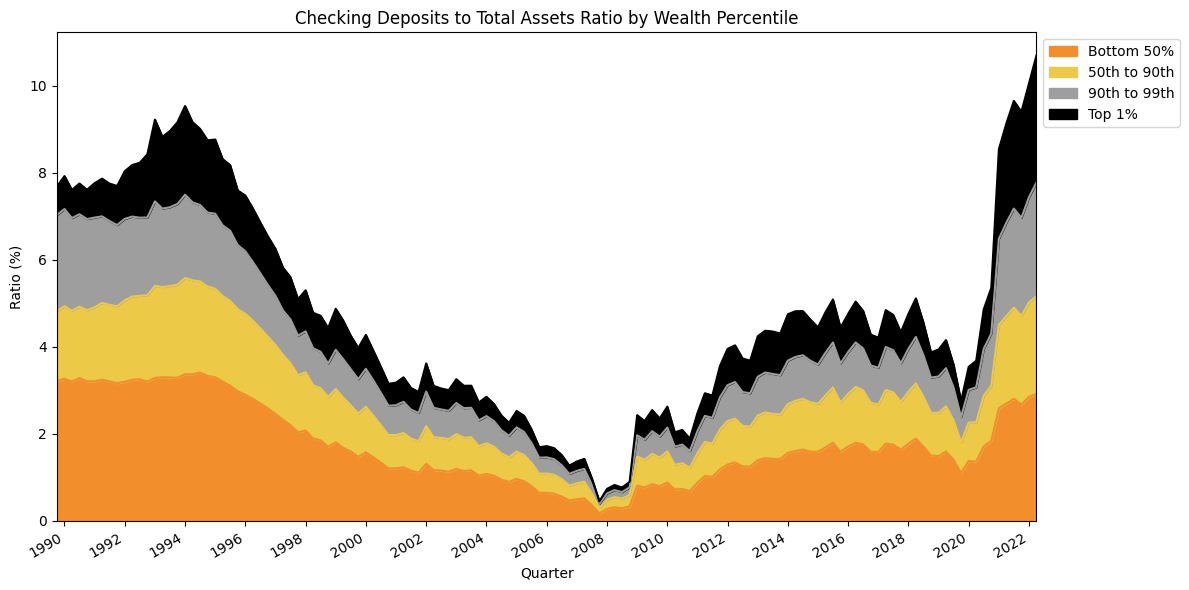

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


def fred_series(series_id: str) -> pd.DataFrame:
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url)
    # Normalize column names; some responses include whitespace or alternate labels.
    df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]
    date_col = "DATE" if "DATE" in df.columns else df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.set_index(date_col)
    # Standardize the data column name to the series id and coerce missing values
    if series_id in df.columns:
        df = df.rename(columns={series_id: series_id})
    else:
        data_col = df.columns[0]
        df = df.rename(columns={data_col: series_id})
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
    return df


# Fetch series as individual dataframes
WFRBSB50194 = fred_series("WFRBSB50194")
WFRBSN40167 = fred_series("WFRBSN40167")
WFRBSN09140 = fred_series("WFRBSN09140")
WFRBST01113 = fred_series("WFRBST01113")
WFRBSB50189 = fred_series("WFRBSB50189")
WFRBSN40162 = fred_series("WFRBSN40162")
WFRBSN09135 = fred_series("WFRBSN09135")
WFRBST01108 = fred_series("WFRBST01108")
BOGZ1FL193020005Q = fred_series("BOGZ1FL193020005Q")
BOGZ1FL192000005A = fred_series("BOGZ1FL192000005A")


def to_quarterly(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Q")
    return out


def to_annual(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Y")
    return out


# Convert to period indexes
WFRBSB50194 = to_quarterly(WFRBSB50194)
WFRBSN40167 = to_quarterly(WFRBSN40167)
WFRBSN09140 = to_quarterly(WFRBSN09140)
WFRBST01113 = to_quarterly(WFRBST01113)
WFRBSB50189 = to_quarterly(WFRBSB50189)
WFRBSN40162 = to_quarterly(WFRBSN40162)
WFRBSN09135 = to_quarterly(WFRBSN09135)
WFRBST01108 = to_quarterly(WFRBST01108)

BOGZ1FL193020005Q = to_quarterly(BOGZ1FL193020005Q)
BOGZ1FL193020005Q = BOGZ1FL193020005Q[
    BOGZ1FL193020005Q.index >= pd.Period("1989Q3", freq="Q")
]

BOGZ1FL192000005A = to_annual(BOGZ1FL192000005A)
BOGZ1FL192000005A = BOGZ1FL192000005A[
    BOGZ1FL192000005A.index >= pd.Period("1989", freq="Y")
]

# Reindex annual data to Q3 and interpolate to quarterly frequency
annual = BOGZ1FL192000005A.copy()
annual.index = annual.index.year
annual_q3 = annual.copy()
annual_q3.index = pd.PeriodIndex([f"{y}Q3" for y in annual.index], freq="Q")
annual_q3 = annual_q3.sort_index()

full_quarters = pd.period_range(
    start=annual_q3.index.min(), end=annual_q3.index.max(), freq="Q"
)
BOGZ1FL192000005A_mod = annual_q3.reindex(full_quarters)
BOGZ1FL192000005A_mod = BOGZ1FL192000005A_mod.interpolate(method="linear")

# Build cashRatios dataframe
combined = pd.concat(
    [
        WFRBSB50194,
        WFRBSN40167,
        WFRBSN09140,
        WFRBST01113,
        WFRBSB50189,
        WFRBSN40162,
        WFRBSN09135,
        WFRBST01108,
        BOGZ1FL193020005Q,
        BOGZ1FL192000005A_mod,
    ],
    axis=1,
).dropna()

cashRatios = pd.DataFrame(index=combined.index)

cashRatios["Bottom 50%"] = (
    combined["WFRBSB50194"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBSB50189"] * combined["BOGZ1FL192000005A"])

cashRatios["50th to 90th"] = (
    combined["WFRBSN40167"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBSN40162"] * combined["BOGZ1FL192000005A"])

cashRatios["90th to 99th"] = (
    combined["WFRBSN09140"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBSN09135"] * combined["BOGZ1FL192000005A"])

cashRatios["Top 1%"] = (
    combined["WFRBST01113"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBST01108"] * combined["BOGZ1FL192000005A"])

# Express as percent
cashRatios = cashRatios * 100

# Stacked area chart
cashRatios_plot = cashRatios.copy()
cashRatios_plot.index = cashRatios_plot.index.to_timestamp(how="end")

# Ensure column order matches desired color order
cashRatios_plot = cashRatios_plot[["Bottom 50%", "50th to 90th", "90th to 99th", "Top 1%"]]

colors = ["#F28E2B", "#EDC948", "#9E9E9E", "#000000"]
ax = cashRatios_plot.plot.area(stacked=True, figsize=(12, 6), color=colors)
ax.set_title("Checking Deposits to Total Assets Ratio by Wealth Percentile")
ax.set_xlabel("Quarter")
ax.set_ylabel("Ratio (%)")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))

# Tighten x-axis to data range and increase tick density to every 2 years
ax.set_xlim(cashRatios_plot.index.min(), cashRatios_plot.index.max())
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()


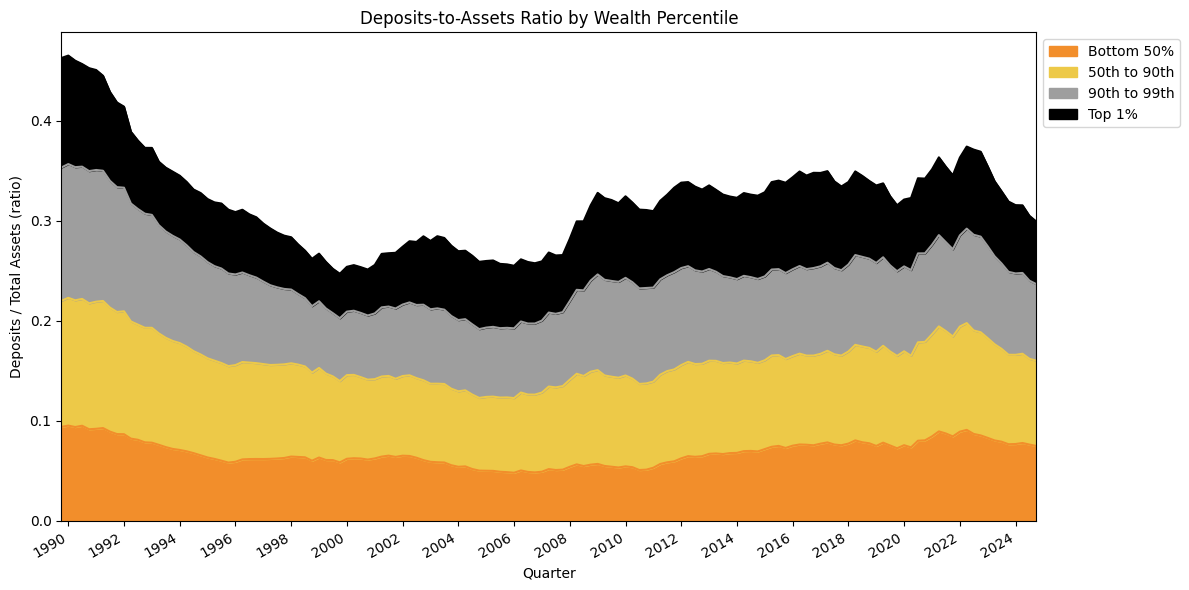

In [2]:
# Alternative chart: deposit level series as a share of total assets by percentile
WFRBLDEB50 = to_quarterly(fred_series("WFRBLDEB50"))
WFRBLDEN40 = to_quarterly(fred_series("WFRBLDEN40"))
WFRBLDEN09 = to_quarterly(fred_series("WFRBLDEN09"))
WFRBLTOP1DE = to_quarterly(fred_series("WFRBLTOP1DE"))

combined_deposits = pd.concat(
    [
        WFRBLDEB50,
        WFRBLDEN40,
        WFRBLDEN09,
        WFRBLTOP1DE,
        WFRBSB50189,
        WFRBSN40162,
        WFRBSN09135,
        WFRBST01108,
        BOGZ1FL192000005A_mod,
    ],
    axis=1,
).dropna()

# Keep the same quarterly start point used in the first chart.
combined_deposits = combined_deposits[
    combined_deposits.index >= pd.Period("1989Q3", freq="Q")
]

depositAssetRatios = pd.DataFrame(index=combined_deposits.index)

depositAssetRatios["Bottom 50%"] = combined_deposits["WFRBLDEB50"] / (
    (combined_deposits["WFRBSB50189"] / 100) * combined_deposits["BOGZ1FL192000005A"]
)

depositAssetRatios["50th to 90th"] = combined_deposits["WFRBLDEN40"] / (
    (combined_deposits["WFRBSN40162"] / 100) * combined_deposits["BOGZ1FL192000005A"]
)

depositAssetRatios["90th to 99th"] = combined_deposits["WFRBLDEN09"] / (
    (combined_deposits["WFRBSN09135"] / 100) * combined_deposits["BOGZ1FL192000005A"]
)

depositAssetRatios["Top 1%"] = combined_deposits["WFRBLTOP1DE"] / (
    (combined_deposits["WFRBST01108"] / 100) * combined_deposits["BOGZ1FL192000005A"]
)

# Keep as ratio values; e.g., 0.09 means 9%.

depositAssetRatios_plot = depositAssetRatios[
    ["Bottom 50%", "50th to 90th", "90th to 99th", "Top 1%"]
].copy()
depositAssetRatios_plot.index = depositAssetRatios_plot.index.to_timestamp(how="end")

import matplotlib.dates as mdates

colors = ["#F28E2B", "#EDC948", "#9E9E9E", "#000000"]
ax = depositAssetRatios_plot.plot.area(stacked=True, figsize=(12, 6), color=colors)
ax.set_title("Deposits-to-Assets Ratio by Wealth Percentile")
ax.set_xlabel("Quarter")
ax.set_ylabel("Deposits / Total Assets (ratio)")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))

ax.set_xlim(depositAssetRatios_plot.index.min(), depositAssetRatios_plot.index.max())
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()


In [3]:
FEDFUNDS = fred_series("FEDFUNDS")

avg_fedfunds_rate = FEDFUNDS["FEDFUNDS"].dropna().mean()
start_date = FEDFUNDS.index.min().date()
end_date = FEDFUNDS.index.max().date()

print(
    f"Average FEDFUNDS rate over full history ({start_date} to {end_date}): "
    f"{avg_fedfunds_rate:.4f}%"
)


Average FEDFUNDS rate over full history (1954-07-01 to 2026-02-01): 4.6016%


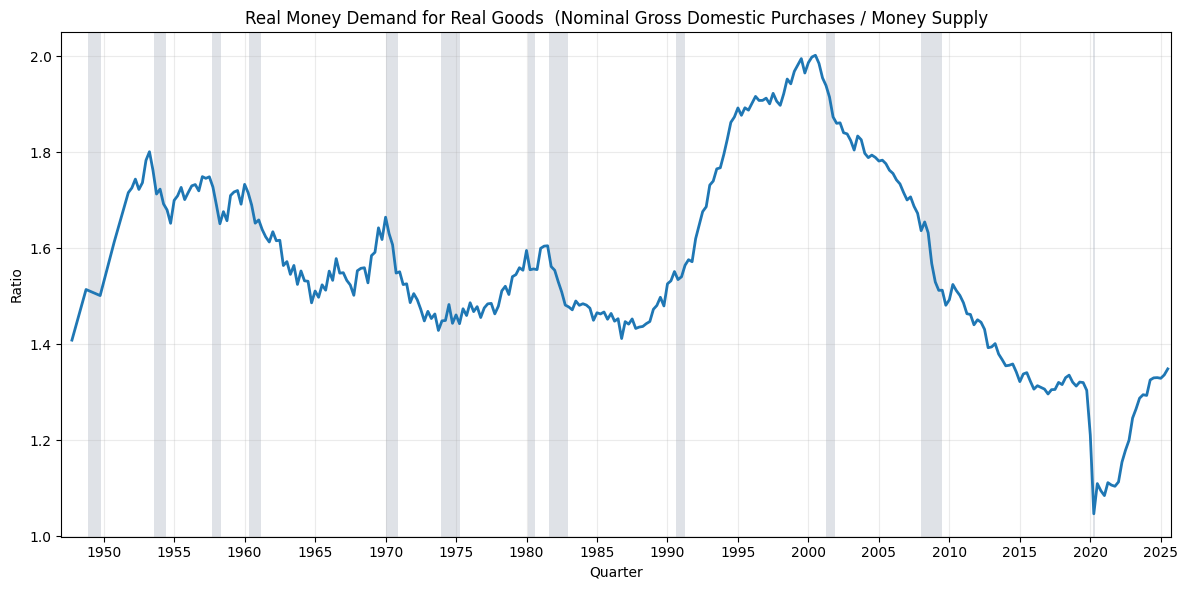

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("\ufeff") for c in df.columns]
        date_col = "DATE" if "DATE" in df.columns else df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.set_index(date_col)
        data_col = series_id if series_id in df.columns else df.columns[0]
        df = df.rename(columns={data_col: series_id})
        df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
        return df

if "to_quarterly" not in globals():
    def to_quarterly(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out.index = out.index.to_period("Q")
        return out.groupby(level=0).mean()


def to_annual(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Y")
    return out.groupby(level=0).mean()


def annual_to_quarterly_linear(df_annual: pd.DataFrame) -> pd.DataFrame:
    annual = df_annual.copy().dropna()
    annual.index = pd.PeriodIndex([f"{p.year}Q4" for p in annual.index], freq="Q")
    full_q = pd.period_range(annual.index.min(), annual.index.max(), freq="Q")
    return annual.reindex(full_q).interpolate(method="linear")


def us_recession_spans() -> list[tuple[pd.Timestamp, pd.Timestamp]]:
    usrec = fred_series("USREC")
    rec = usrec["USREC"].dropna().astype(float)

    spans = []
    in_recession = False
    recession_start = None

    for dt, val in rec.items():
        if val >= 0.5 and not in_recession:
            recession_start = dt
            in_recession = True
        elif val < 0.5 and in_recession:
            spans.append((recession_start, dt))
            in_recession = False

    if in_recession and recession_start is not None:
        spans.append((recession_start, rec.index.max() + pd.offsets.MonthBegin(1)))

    return spans


FSDP = to_quarterly(fred_series("FSDP"))
BOGZ1FL703130005Q = to_quarterly(fred_series("BOGZ1FL703130005Q"))
BOGZ1FL703127005Q = to_quarterly(fred_series("BOGZ1FL703127005Q"))
BOGZ1FL713125005A = annual_to_quarterly_linear(to_annual(fred_series("BOGZ1FL713125005A")))

ratio_df = pd.concat(
    [FSDP, BOGZ1FL703130005Q, BOGZ1FL703127005Q, BOGZ1FL713125005A], axis=1
).dropna()
ratio_df["ratio"] = (ratio_df["FSDP"] * 1000) / (
    ratio_df["BOGZ1FL703130005Q"]
    + ratio_df["BOGZ1FL703127005Q"]
    + ratio_df["BOGZ1FL713125005A"]
)

start_q = pd.Period("1947Q1", freq="Q")
end_q = pd.Period("2025Q3", freq="Q")
ratio_window = ratio_df.loc[start_q:end_q, ["ratio"]].dropna()

ratio_plot = ratio_window.copy()
ratio_plot.index = ratio_plot.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ratio_plot.index, ratio_plot["ratio"], color="#1f77b4", linewidth=2)
ax.set_title(
    "Real Money Demand for Real Goods  (Nominal Gross Domestic Purchases / "
    "Money Supply"
)
ax.set_xlabel("Quarter")
ax.set_ylabel("Ratio")
ax.grid(alpha=0.25)

x_start = start_q.start_time
x_end = end_q.end_time
for rec_start, rec_end in us_recession_spans():
    span_start = max(rec_start, x_start)
    span_end = min(rec_end, x_end)
    if span_start < span_end:
        ax.axvspan(span_start, span_end, color="#c0c7d1", alpha=0.5, lw=0)

ax.set_xlim(x_start, x_end)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()


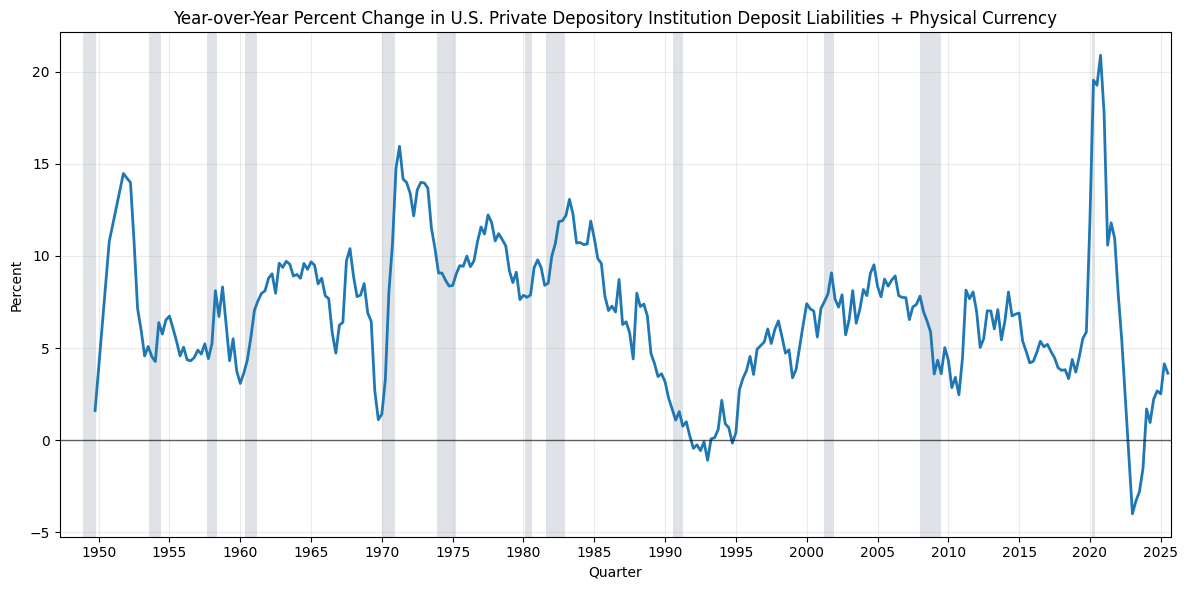

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]
        date_col = "DATE" if "DATE" in df.columns else df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.set_index(date_col)
        data_col = series_id if series_id in df.columns else df.columns[0]
        df = df.rename(columns={data_col: series_id})
        df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
        return df

if "to_quarterly" not in globals():
    def to_quarterly(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out.index = out.index.to_period("Q")
        return out.groupby(level=0).mean()

if "to_annual" not in globals():
    def to_annual(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out.index = out.index.to_period("Y")
        return out.groupby(level=0).mean()

if "annual_to_quarterly_linear" not in globals():
    def annual_to_quarterly_linear(df_annual: pd.DataFrame) -> pd.DataFrame:
        annual = df_annual.copy().dropna()
        annual.index = pd.PeriodIndex([f"{p.year}Q4" for p in annual.index], freq="Q")
        full_q = pd.period_range(annual.index.min(), annual.index.max(), freq="Q")
        return annual.reindex(full_q).interpolate(method="linear")

if "us_recession_spans" not in globals():
    def us_recession_spans() -> list[tuple[pd.Timestamp, pd.Timestamp]]:
        usrec = fred_series("USREC")
        rec = usrec["USREC"].dropna().astype(float)

        spans = []
        in_recession = False
        recession_start = None

        for dt, val in rec.items():
            if val >= 0.5 and not in_recession:
                recession_start = dt
                in_recession = True
            elif val < 0.5 and in_recession:
                spans.append((recession_start, dt))
                in_recession = False

        if in_recession and recession_start is not None:
            spans.append((recession_start, rec.index.max() + pd.offsets.MonthBegin(1)))

        return spans


BOGZ1FL703130005Q = to_quarterly(fred_series("BOGZ1FL703130005Q"))
BOGZ1FL703127005Q = to_quarterly(fred_series("BOGZ1FL703127005Q"))
BOGZ1FL713125005A = annual_to_quarterly_linear(to_annual(fred_series("BOGZ1FL713125005A")))

deposits_df = pd.concat(
    [BOGZ1FL703130005Q, BOGZ1FL703127005Q, BOGZ1FL713125005A], axis=1
).dropna()
deposits_df["total_deposit_liabilities_plus_currency"] = (
    deposits_df["BOGZ1FL703130005Q"]
    + deposits_df["BOGZ1FL703127005Q"]
    + deposits_df["BOGZ1FL713125005A"]
)

# Year-over-year percent change for quarterly data (t vs t-4).
deposits_df["yoy_pct_change"] = (
    (
        deposits_df["total_deposit_liabilities_plus_currency"]
        / deposits_df["total_deposit_liabilities_plus_currency"].shift(4)
    )
    - 1
) * 100

start_q = pd.Period("1947Q2", freq="Q")
end_q = pd.Period("2025Q3", freq="Q")
growth_window = deposits_df.loc[start_q:end_q, ["yoy_pct_change"]].dropna()

growth_plot = growth_window.copy()
growth_plot.index = growth_plot.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    growth_plot.index,
    growth_plot["yoy_pct_change"],
    color="#1f77b4",
    linewidth=2,
)
ax.set_title(
    "Year-over-Year Percent Change in U.S. Private Depository Institution "
    "Deposit Liabilities + Physical Currency"
)
ax.set_xlabel("Quarter")
ax.set_ylabel("Percent")
ax.axhline(0, color="black", linewidth=1, alpha=0.6)
ax.grid(alpha=0.25)

x_start = start_q.start_time
x_end = end_q.end_time
for rec_start, rec_end in us_recession_spans():
    span_start = max(rec_start, x_start)
    span_end = min(rec_end, x_end)
    if span_start < span_end:
        ax.axvspan(span_start, span_end, color="#c0c7d1", alpha=0.5, lw=0)

ax.set_xlim(x_start, x_end)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()



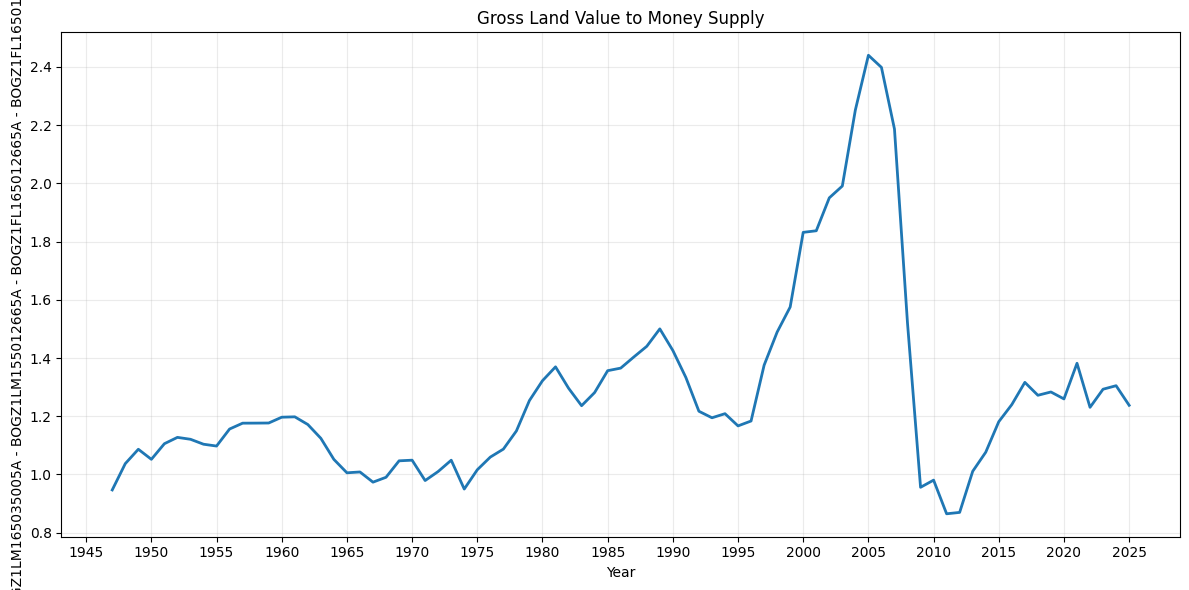

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]

        date_col = "DATE" if "DATE" in df.columns else df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        if df[date_col].isna().all():
            raise ValueError(
                f"FRED response for {series_id} does not contain a parseable date column. "
                f"Columns: {list(df.columns)}"
            )
        df = df.set_index(date_col)

        if series_id in df.columns:
            data_col = series_id
        else:
            candidate_cols = [c for c in df.columns if c != date_col]
            if not candidate_cols:
                raise ValueError(
                    f"FRED response for {series_id} has no data column. Columns: {list(df.columns)}"
                )
            data_col = candidate_cols[0]

        df[series_id] = pd.to_numeric(df[data_col], errors="coerce")
        return df[[series_id]]


def to_annual_mean(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Y")
    return out.groupby(level=0).mean()


BOGZ1FL105010005A = to_annual_mean(fred_series("BOGZ1FL105010005A"))
BOGZ1FL115010005A = to_annual_mean(fred_series("BOGZ1FL115010005A"))
BOGZ1LM155035015A = to_annual_mean(fred_series("BOGZ1LM155035015A"))
BOGZ1LM165035005A = to_annual_mean(fred_series("BOGZ1LM165035005A"))
BOGZ1LM155012665A = to_annual_mean(fred_series("BOGZ1LM155012665A"))
BOGZ1FL165012665A = to_annual_mean(fred_series("BOGZ1FL165012665A"))
BOGZ1FL165013665A = to_annual_mean(fred_series("BOGZ1FL165013665A"))
BOGZ1FL703130005Q = to_annual_mean(fred_series("BOGZ1FL703130005Q"))
BOGZ1FL703127005Q = to_annual_mean(fred_series("BOGZ1FL703127005Q"))
BOGZ1FL713125005A = to_annual_mean(fred_series("BOGZ1FL713125005A"))

ratio_df = pd.concat(
    [
        BOGZ1FL105010005A,
        BOGZ1FL115010005A,
        BOGZ1LM155035015A,
        BOGZ1LM165035005A,
        BOGZ1LM155012665A,
        BOGZ1FL165012665A,
        BOGZ1FL165013665A,
        BOGZ1FL703130005Q,
        BOGZ1FL703127005Q,
        BOGZ1FL713125005A,
    ],
    axis=1,
).dropna()
ratio_df["gross_commercial_land_value_adjusted"] = (
    ratio_df["BOGZ1FL105010005A"]
    + ratio_df["BOGZ1FL115010005A"]
    + ratio_df["BOGZ1LM155035015A"]
    + ratio_df["BOGZ1LM165035005A"]
    - ratio_df["BOGZ1LM155012665A"]
    - ratio_df["BOGZ1FL165012665A"]
    - ratio_df["BOGZ1FL165013665A"]
)
ratio_df["money_supply_proxy"] = (
    ratio_df["BOGZ1FL703130005Q"]
    + ratio_df["BOGZ1FL703127005Q"]
    + ratio_df["BOGZ1FL713125005A"]
)
ratio_df = ratio_df[ratio_df["money_supply_proxy"] != 0]
ratio_df["Gross_Commercial_Land_Value_to_Money_Supply"] = (
    ratio_df["gross_commercial_land_value_adjusted"] / ratio_df["money_supply_proxy"]
)

start_y = pd.Period("1947", freq="Y")
end_y = pd.Period("2025", freq="Y")
series = ratio_df.loc[
    start_y:end_y, "Gross_Commercial_Land_Value_to_Money_Supply"
].dropna()

plot = series.copy()
plot.index = plot.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot.index, plot.values, color="#1f77b4", linewidth=2)
ax.set_title("Gross Land Value to Money Supply")
ax.set_xlabel("Year")
ax.set_ylabel(
    "(BOGZ1FL105010005A + BOGZ1FL115010005A + BOGZ1LM155035015A + BOGZ1LM165035005A "
    "- BOGZ1LM155012665A - BOGZ1FL165012665A - BOGZ1FL165013665A) / "
    "(BOGZ1FL703130005Q + BOGZ1FL703127005Q + BOGZ1FL713125005A)"
)
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()



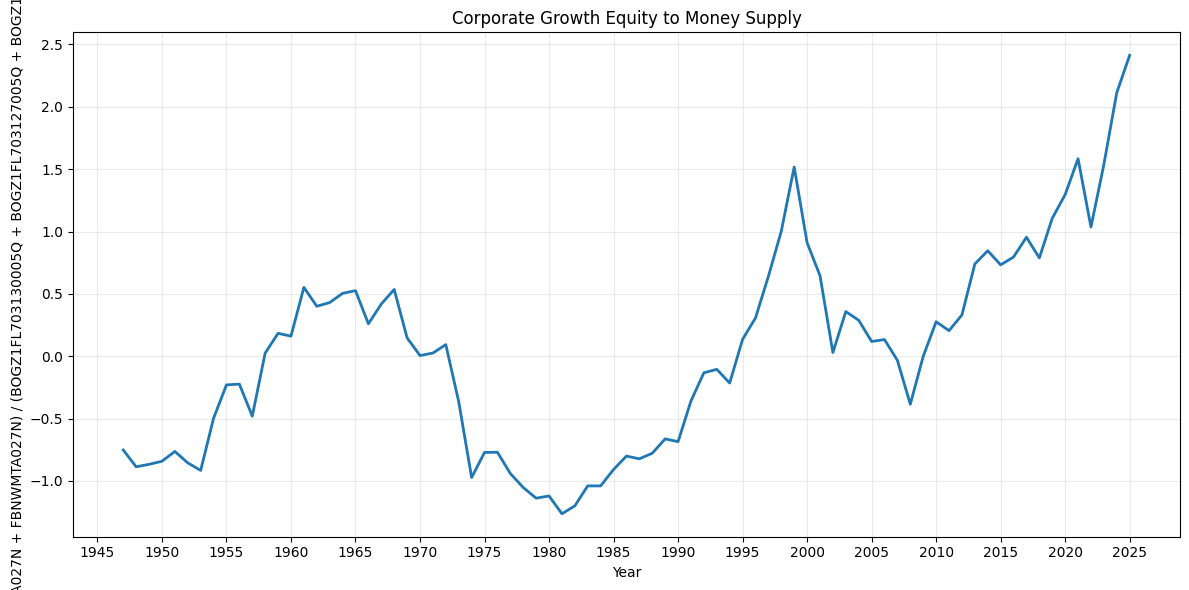

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]

        date_col = "DATE" if "DATE" in df.columns else df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        if df[date_col].isna().all():
            raise ValueError(
                f"FRED response for {series_id} does not contain a parseable date column. "
                f"Columns: {list(df.columns)}"
            )
        df = df.set_index(date_col)

        if series_id in df.columns:
            data_col = series_id
        else:
            candidate_cols = [c for c in df.columns if c != date_col]
            if not candidate_cols:
                raise ValueError(
                    f"FRED response for {series_id} has no data column. Columns: {list(df.columns)}"
                )
            data_col = candidate_cols[0]

        df[series_id] = pd.to_numeric(df[data_col], errors="coerce")
        return df[[series_id]]


def to_annual_mean(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Y")
    return out.groupby(level=0).mean()


NCBIMTA027N = to_annual_mean(fred_series("NCBIMTA027N"))
FBNWMTA027N = to_annual_mean(fred_series("FBNWMTA027N"))
BOGZ1FL703130005Q = to_annual_mean(fred_series("BOGZ1FL703130005Q"))
BOGZ1FL703127005Q = to_annual_mean(fred_series("BOGZ1FL703127005Q"))
BOGZ1FL713125005A = to_annual_mean(fred_series("BOGZ1FL713125005A"))

ratio_df = pd.concat(
    [
        NCBIMTA027N,
        FBNWMTA027N,
        BOGZ1FL703130005Q,
        BOGZ1FL703127005Q,
        BOGZ1FL713125005A,
    ],
    axis=1,
).dropna()
ratio_df["money_supply_proxy"] = (
    ratio_df["BOGZ1FL703130005Q"]
    + ratio_df["BOGZ1FL703127005Q"]
    + ratio_df["BOGZ1FL713125005A"]
)
ratio_df = ratio_df[ratio_df["money_supply_proxy"] != 0]
ratio_df["Corporate_Growth_Equity_to_Money_Supply"] = (
    -1.0 * (ratio_df["NCBIMTA027N"] + ratio_df["FBNWMTA027N"]) / ratio_df["money_supply_proxy"]
)

start_y = pd.Period("1947", freq="Y")
end_y = pd.Period("2025", freq="Y")
series = ratio_df.loc[start_y:end_y, "Corporate_Growth_Equity_to_Money_Supply"].dropna()

plot = series.copy()
plot.index = plot.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot.index, plot.values, color="#1f77b4", linewidth=2)
ax.set_title("Corporate Growth Equity to Money Supply")
ax.set_xlabel("Year")
ax.set_ylabel(
    "-1 * (NCBIMTA027N + FBNWMTA027N) / "
    "(BOGZ1FL703130005Q + BOGZ1FL703127005Q + BOGZ1FL713125005A)"
)
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()



In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from IPython.display import display

base_dir = Path("CPI_relative_importance")


def normalize_label(text) -> str:
    s = str(text).replace("\u2019", "'").replace(".", " ").lower()
    return " ".join(s.split())


def normalize_key(text) -> str:
    return "".join(ch for ch in normalize_label(text).replace("'", "") if ch.isalnum())


def to_float(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    s = (
        str(value)
        .strip()
        .replace(",", "")
        .replace("\u2212", "-")
        .replace(" .", ".")
        .replace(". ", ".")
    )
    s = "".join(ch for ch in s if ch.isdigit() or ch in ".-")
    if s.startswith("."):
        s = "0" + s
    if s.startswith("-."):
        s = "-0" + s[1:]
    if s.count(".") > 1:
        first_dot = s.find(".")
        s = s[: first_dot + 1] + s[first_dot + 1 :].replace(".", "")

    try:
        return float(s)
    except ValueError:
        return np.nan


def entries_from_column(df: pd.DataFrame, label_col, value_col) -> list[dict]:
    rows = []
    for label, value in zip(df[label_col], df[value_col]):
        val = to_float(value)
        if pd.isna(val):
            continue
        key = normalize_key(label)
        if not key:
            continue
        rows.append({"label": str(label), "key": key, "value": val})
    return rows


def pick_exact(entries: list[dict], keys: set[str]):
    vals = [e["value"] for e in entries if e["key"] in keys]
    return max(vals) if vals else np.nan


def pick_oer(entries: list[dict]):
    candidates = [
        e
        for e in entries
        if "ownersequivalentrent" in e["key"] and "unsampled" not in e["key"]
    ]
    if not candidates:
        return np.nan

    def score(e):
        key = e["key"]
        if "ofresidences" in key:
            return 0
        if key == "ownersequivalentrent":
            return 1
        if "ofprimaryresidence" in key:
            return 2
        return 3

    candidates = sorted(candidates, key=lambda e: (score(e), -e["value"]))
    return candidates[0]["value"]


def extract_targets(entries: list[dict]):
    durables = pick_exact(entries, {"durables"})
    nondurables = pick_exact(entries, {"nondurables"})
    services = pick_exact(entries, {"services", "allservices"})
    oer = pick_oer(entries)
    return durables, nondurables, services, oer


def pick_owner_occupied_base(entries: list[dict]):
    """
    Pick the broad pre-1983 owner-occupied housing aggregate used for OER backcasting.

    Priority order:
    1) Homeowners' costs
    2) Homeownership
    3) Home purchase and upkeep

    We intentionally do NOT build this from subtraction residuals to avoid nested
    item double-count issues (for example, taxes and insurance vs property-tax
    subrows) and to keep the base aligned with the broad historical aggregate.
    """
    candidates = [
        ("homeownerscosts", {"homeownerscosts", "homeownerscost"}),
        ("homeownership", {"homeownership"}),
        (
            "homepurchaseandupkeep",
            {"homepurchaseandupkeep", "homepurchaseupkeep"},
        ),
    ]
    for canonical, keys in candidates:
        value = pick_exact(entries, keys)
        if pd.notna(value):
            return value, canonical
    return np.nan, ""


# (a) historical workbook parser: 1947-1986
def parse_historical_workbook(base: Path) -> dict[int, dict]:
    file_path = base / "historical-relative-importance-1947-1986.xlsx"
    out = {}

    def pack(entries, year, source, note=""):
        d, n, s, o = extract_targets(entries)
        owner_base, owner_base_label = pick_owner_occupied_base(entries)
        return {
            "durables": d,
            "nondurables": n,
            "services": s,
            "owners_equivalent_rent": o,
            "owner_occupied_base": owner_base,
            "owner_occupied_base_label": owner_base_label,
            "source_file": source,
            "note": note,
        }

    # 1947-1949 average sheet expanded to three yearly rows.
    df = pd.read_excel(file_path, sheet_name="1947-1949", header=1)
    entries = entries_from_column(df, df.columns[0], df.columns[1])
    packed = pack(
        entries,
        1949,
        "historical-relative-importance-1947-1986.xlsx:1947-1949",
        "Expanded from 1947-1949 average sheet.",
    )
    for year in [1947, 1948, 1949]:
        out[year] = dict(packed)

    # 1951 exists but requested aggregates are not directly identifiable.
    out[1951] = {
        "durables": np.nan,
        "nondurables": np.nan,
        "services": np.nan,
        "owners_equivalent_rent": np.nan,
        "owner_occupied_base": np.nan,
        "owner_occupied_base_label": "",
        "source_file": "historical-relative-importance-1947-1986.xlsx:1951",
        "note": "No directly identifiable aggregate rows for requested categories; interpolated from adjacent years.",
    }

    # Multi-year sheets with explicit December year columns.
    for sheet in ["1952-1960", "1961-1976"]:
        df = pd.read_excel(file_path, sheet_name=sheet, header=1)
        label_col = df.columns[0]
        for col in df.columns[1:]:
            m = re.search(r"(19\d{2})", str(col))
            if not m:
                continue
            year = int(m.group(1))
            entries = entries_from_column(df, label_col, col)
            out[year] = pack(
                entries,
                year,
                f"historical-relative-importance-1947-1986.xlsx:{sheet}",
                "",
            )

    # 1977-1979 sheet: use All Urban Consumers columns.
    df = pd.read_excel(file_path, sheet_name="1977-1979", header=1)
    label_col = df.columns[0]
    for col in df.columns[1:]:
        col_str = str(col)
        if "all urban consumers" not in col_str.lower():
            continue
        m = re.search(r"(19\d{2})", col_str)
        if not m:
            continue
        year = int(m.group(1))
        entries = entries_from_column(df, label_col, col)
        out[year] = pack(
            entries,
            year,
            "historical-relative-importance-1947-1986.xlsx:1977-1979",
            "",
        )

    # 1980-1981: two-level headers.
    df = pd.read_excel(file_path, sheet_name="1980-1981", header=[1, 2])
    label_col = df.columns[0]
    for col in df.columns[1:]:
        top = str(col[0]).lower()
        bottom = str(col[1])
        if "all urban consumers" not in top:
            continue
        m = re.search(r"(19\d{2})", bottom)
        if not m:
            continue
        year = int(m.group(1))
        entries = entries_from_column(df, label_col, col)
        out[year] = pack(
            entries,
            year,
            "historical-relative-importance-1947-1986.xlsx:1980-1981",
            "",
        )

    # 1982-1985 single-year sheets: use main/current CPI-U column only.
    for sheet in ["1982", "1983", "1984", "1985"]:
        df = pd.read_excel(file_path, sheet_name=sheet, header=1)
        label_col = df.columns[0]
        cpi_u_col = [
            c
            for c in df.columns[1:]
            if "cpi-u" in str(c).lower() and "old series" not in str(c).lower()
        ][0]
        year = int(sheet)
        entries = entries_from_column(df, label_col, cpi_u_col)
        out[year] = pack(
            entries,
            year,
            f"historical-relative-importance-1947-1986.xlsx:{sheet}",
            "",
        )

    # 1986 has a different header row offset.
    df = pd.read_excel(file_path, sheet_name="1986", header=2)
    label_col = df.columns[0]
    cpi_u_col = [c for c in df.columns[1:] if "cpi-u" in str(c).lower()][0]
    entries = entries_from_column(df, label_col, cpi_u_col)
    out[1986] = pack(
        entries,
        1986,
        "historical-relative-importance-1947-1986.xlsx:1986",
        "",
    )

    return out


# Common TXT row parser used by 1987-1999 and 2000-2019 families.
def parse_txt_rows(path: Path) -> list[dict]:
    rows = []
    for raw_line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        parts = raw_line.strip().split()
        if len(parts) < 3:
            continue

        cpi_u = to_float(parts[-2])
        cpi_w = to_float(parts[-1])
        if pd.isna(cpi_u) or pd.isna(cpi_w):
            continue

        lead = parts[:-2]
        if not lead:
            continue

        code = None
        if re.fullmatch(r"[A-Z0-9]{2,8}", lead[0] or ""):
            code = lead[0]
            label = " ".join(lead[1:])
            if not label:
                continue
        else:
            label = " ".join(lead)

        label = " ".join(label.replace(".", " ").split())
        rows.append(
            {
                "code": code,
                "label": label,
                "key": normalize_key(label),
                "cpi_u": cpi_u,
                "cpi_w": cpi_w,
            }
        )
    return rows


# (b) 1987-1999 TXT parser
def parse_1987_1999_txt(base: Path) -> dict[int, dict]:
    out = {}
    for year in range(1987, 2000):
        file_path = base / f"{year}.txt"
        rows = parse_txt_rows(file_path)
        entries = [{"label": r["label"], "key": r["key"], "value": r["cpi_u"]} for r in rows]

        d, n, s, o = extract_targets(entries)
        by_code = {r["code"]: r["cpi_u"] for r in rows if r["code"]}
        d = by_code.get("SAD", d)
        n = by_code.get("SAN", n)
        s = by_code.get("SAS", s)
        o = by_code.get("SE2201", o)

        out[year] = {
            "durables": d,
            "nondurables": n,
            "services": s,
            "owners_equivalent_rent": o,
            "owner_occupied_base": np.nan,
            "owner_occupied_base_label": "",
            "source_file": file_path.name,
            "note": "",
        }
    return out


# (c) 2000-2019 TXT parser
def parse_2000_2019_txt(base: Path) -> dict[int, dict]:
    out = {}
    for year in range(2000, 2020):
        file_path = base / f"{year}.txt"
        rows = parse_txt_rows(file_path)
        entries = [{"label": r["label"], "key": r["key"], "value": r["cpi_u"]} for r in rows]
        d, n, s, o = extract_targets(entries)

        out[year] = {
            "durables": d,
            "nondurables": n,
            "services": s,
            "owners_equivalent_rent": o,
            "owner_occupied_base": np.nan,
            "owner_occupied_base_label": "",
            "source_file": file_path.name,
            "note": "",
        }
    return out


# (d) 2020-2025 XLSX parser

def parse_2020_2025_xlsx(base: Path) -> dict[int, dict]:
    out = {}
    for year in range(2020, 2026):
        file_path = base / f"{year}.xlsx"
        df = pd.read_excel(file_path, sheet_name="Table 1", header=3)
        item_col = [c for c in df.columns if "item and group" in str(c).lower()][0]
        cpi_u_col = df.columns[2]

        entries = entries_from_column(df, item_col, cpi_u_col)
        d, n, s, o = extract_targets(entries)

        out[year] = {
            "durables": d,
            "nondurables": n,
            "services": s,
            "owners_equivalent_rent": o,
            "owner_occupied_base": np.nan,
            "owner_occupied_base_label": "",
            "source_file": f"{file_path.name}:Table 1",
            "note": "",
        }
    return out


# Build unified yearly frame.
records = {}
for parser in [
    parse_historical_workbook,
    parse_1987_1999_txt,
    parse_2000_2019_txt,
    parse_2020_2025_xlsx,
]:
    records.update(parser(base_dir))

all_years = list(range(1947, 2026))
working = pd.DataFrame(
    index=all_years,
    columns=[
        "durables",
        "nondurables",
        "services",
        "owners_equivalent_rent",
        "owner_occupied_base",
        "owner_occupied_base_label",
        "source_file",
        "note",
    ],
)

for year, values in records.items():
    for key, val in values.items():
        working.at[year, key] = val

for col in [
    "durables",
    "nondurables",
    "services",
    "owners_equivalent_rent",
    "owner_occupied_base",
]:
    working[col] = pd.to_numeric(working[col], errors="coerce")

# Fill aggregate share gaps by interpolation (required for 1950/1951 and sparse historical years).
missing_before_fill = working[["durables", "nondurables", "services"]].isna().any(axis=1)
for col in ["durables", "nondurables", "services"]:
    working[col] = working[col].interpolate(method="linear", limit_area="inside")

# Required caveats for 1950 and 1951.
if pd.isna(working.at[1950, "source_file"]):
    working.at[1950, "source_file"] = "interpolated_from_adjacent_years"
working.at[1950, "note"] = "1950 unavailable directly; filled by linear interpolation from adjacent years."
working.at[1951, "source_file"] = "historical-relative-importance-1947-1986.xlsx:1951 (interpolated)"
working.at[1951, "note"] = "1951 aggregates not directly identifiable; filled by linear interpolation from adjacent years."

for year in all_years:
    if year in [1950, 1951]:
        continue
    if bool(missing_before_fill.loc[year]):
        base_note = "" if pd.isna(working.at[year, "note"]) else str(working.at[year, "note"]).strip()
        msg = "Some aggregate values missing in source; filled by linear interpolation from adjacent years."
        if msg not in base_note:
            working.at[year, "note"] = (base_note + " " + msg).strip()

for year in [1947, 1948, 1949]:
    base_note = "" if pd.isna(working.at[year, "note"]) else str(working.at[year, "note"]).strip()
    msg = "Expanded from 1947-1949 average sheet."
    if msg not in base_note:
        working.at[year, "note"] = (base_note + " " + msg).strip()

# Build pre-1983 homeowner cost component from mapped broad owner-occupied
# housing aggregates (no residual subtraction).
working["pre_1983_homeowner_cost_component"] = np.nan

anchor_year = 1982
anchor_oer = working.at[anchor_year, "owners_equivalent_rent"]
anchor_base = working.at[anchor_year, "owner_occupied_base"]
if pd.isna(anchor_oer):
    raise AssertionError("1982 explicit OER row missing; cannot calibrate pre-1983 mapping.")
if pd.isna(anchor_base) or anchor_base == 0:
    raise AssertionError("1982 owner-occupied housing aggregate missing; cannot calibrate pre-1983 mapping.")
bridge_factor = anchor_oer / anchor_base

pre_years = [y for y in all_years if y < 1983]
owner_base_pre_observed = working.loc[pre_years, "owner_occupied_base"].copy()
owner_base_pre_filled = owner_base_pre_observed.copy()

# Fill internal gaps first.
owner_base_pre_filled = owner_base_pre_filled.interpolate(method="linear", limit_area="inside")

# Backcast leading missing years from the mapped owner-occupied base series.
valid_idx = owner_base_pre_filled.dropna().index.tolist()
if valid_idx:
    first_valid = valid_idx[0]
    if len(valid_idx) >= 2:
        second_valid = valid_idx[1]
        year_gap = second_valid - first_valid
        slope = (owner_base_pre_filled.at[second_valid] - owner_base_pre_filled.at[first_valid]) / year_gap
    else:
        slope = 0.0
    for year in pre_years:
        if year >= first_valid:
            continue
        owner_base_pre_filled.at[year] = owner_base_pre_filled.at[first_valid] - slope * (first_valid - year)
        if owner_base_pre_filled.at[year] < 0:
            owner_base_pre_filled.at[year] = np.nan

# Final guard for any stragglers after backcast.
owner_base_pre_filled = owner_base_pre_filled.interpolate(method="linear", limit_direction="both")
mapped_component_pre = owner_base_pre_filled * bridge_factor

initial_status = {}
for year in pre_years:
    oer_val = working.at[year, "owners_equivalent_rent"]
    observed_base = owner_base_pre_observed.at[year]

    if pd.notna(oer_val):
        component_val = oer_val
        initial_status[year] = "direct_observed_oer"
    else:
        component_val = mapped_component_pre.at[year]
        if pd.notna(observed_base):
            base_label = str(working.at[year, "owner_occupied_base_label"]).strip() or "owner_occupied_base"
            initial_status[year] = f"mapped_from_{base_label}"
        else:
            initial_status[year] = "backcast_or_interpolated_mapped_owner_base"

    working.at[year, "pre_1983_homeowner_cost_component"] = component_val

# Define services_excl_oer with requested rule:
# - use explicit OER whenever present (1983+ and 1982 bridge year)
# - otherwise (pre-1983) subtract mapped/backcast homeowner component
services_excl = []
for year in all_years:
    services_val = working.at[year, "services"]
    oer_val = working.at[year, "owners_equivalent_rent"]
    if pd.notna(oer_val):
        services_excl.append(services_val - oer_val)
    elif year < 1983:
        services_excl.append(services_val - working.at[year, "pre_1983_homeowner_cost_component"])
    else:
        services_excl.append(np.nan)
working["services_excl_oer"] = services_excl

# Notes for proxy/estimate provenance.
for year in pre_years:
    status = initial_status.get(year)
    if status is None:
        continue

    base_note = "" if pd.isna(working.at[year, "note"]) else str(working.at[year, "note"]).strip()

    if status == "direct_observed_oer":
        extra = "Pre-1983 homeowner component uses directly observed OER row (1982 bridge year)."
    elif status.startswith("mapped_from_"):
        mapped_source = status.replace("mapped_from_", "")
        extra = (
            f"Pre-1983 homeowner component is estimated by mapping '{mapped_source}' to the OER concept "
            f"with a 1982 bridge factor ({bridge_factor:.6f})."
        )
    else:
        extra = (
            f"Pre-1983 homeowner component is estimated by interpolation/backcast of the mapped owner-occupied "
            f"housing aggregate using the 1982 bridge factor ({bridge_factor:.6f})."
        )

    if extra not in base_note:
        working.at[year, "note"] = (base_note + " " + extra).strip()

# Final DataFrame (owners_equivalent_rent added back).
cpi_u_relative_importance = working[
    [
        "durables",
        "nondurables",
        "owners_equivalent_rent",
        "pre_1983_homeowner_cost_component",
        "services_excl_oer",
        "source_file",
        "note",
    ]
].copy()
cpi_u_relative_importance.index.name = "year"
cpi_u_relative_importance = cpi_u_relative_importance.sort_index()

# Show compact audit view only (first 15 and last 15 rows).
audit_view = pd.concat(
    [
        cpi_u_relative_importance.head(15),
        cpi_u_relative_importance.tail(15),
    ],
    axis=0,
)
display(audit_view)

# Sanity checks required by prompt
for check_year in [1987, 2000, 2010, 2025]:
    assert check_year in cpi_u_relative_importance.index, f"Missing year {check_year}"
    services_val = working.at[check_year, "services"]
    oer_val = working.at[check_year, "owners_equivalent_rent"]
    assert pd.notna(oer_val), f"Expected explicit OER for {check_year}"
    calc = cpi_u_relative_importance.at[check_year, "services_excl_oer"]
    assert np.isclose(calc, services_val - oer_val, atol=1e-9), (
        f"services_excl_oer mismatch for {check_year}: {calc} vs {services_val - oer_val}"
    )

# Explicit check for 1982 anchor behavior.
assert pd.notna(working.at[1982, "owners_equivalent_rent"]), "1982 OER anchor missing"
assert np.isclose(
    working.at[1982, "services_excl_oer"],
    working.at[1982, "services"] - working.at[1982, "owners_equivalent_rent"],
    atol=1e-9,
), "1982 services_excl_oer does not use explicit OER"

# Additional sanity check requested: pre-1983 homeowner component should be
# high single digits/teens, not around 1.0.
pre_1983_component = working.loc[working.index < 1983, "pre_1983_homeowner_cost_component"].dropna()
assert not pre_1983_component.empty, "Pre-1983 homeowner component is empty."
assert pre_1983_component.median() >= 8.0, (
    f"Pre-1983 homeowner component median too small: {pre_1983_component.median():.3f}"
)
assert pre_1983_component.min() >= 5.0, (
    f"Pre-1983 homeowner component minimum too small: {pre_1983_component.min():.3f}"
)

print(
    "Sanity checks passed for 1987/2000/2010/2025, 1982 anchor handling, "
    "and pre-1983 homeowner component magnitude."
)


,durables,nondurables,owners_equivalent_rent,pre_1983_homeowner_cost_component,services_excl_oer,source_file,note
year,,,,,,,
1947,6.700000,66.200,NaN,11.010857,16.089143,historical-relative-importance-1947-1986.xlsx:...,Expanded from 1947-1949 average sheet. Pre-198...
1948,6.700000,66.200,NaN,11.069166,16.030834,historical-relative-importance-1947-1986.xlsx:...,Expanded from 1947-1949 average sheet. Pre-198...
1949,6.700000,66.200,NaN,11.127476,15.972524,historical-relative-importance-1947-1986.xlsx:...,Expanded from 1947-1949 average sheet. Pre-198...
1950,7.562500,64.350,NaN,11.185786,16.801714,interpolated_from_adjacent_years,1950 unavailable directly; filled by linear in...
1951,8.425000,62.500,NaN,11.244096,17.630904,historical-relative-importance-1947-1986.xlsx:...,1951 aggregates not directly identifiable; fil...
1952,9.287500,60.650,NaN,11.302406,18.460094,historical-relative-importance-1947-1986.xlsx:...,Some aggregate values missing in source; fille...
1953,10.150000,58.800,NaN,11.360716,19.289284,historical-relative-importance-1947-1986.xlsx:...,Some aggregate values missing in source; fille...
1954,11.012500,56.950,NaN,11.632829,19.904671,historical-relative-importance-1947-1986.xlsx:...,Some aggregate values missing in source; fille...
1955,11.875000,55.100,NaN,11.710576,20.714424,historical-relative-importance-1947-1986.xlsx:...,Some aggregate values missing in source; fille...


Sanity checks passed for 1987/2000/2010/2025, 1982 anchor handling, and pre-1983 homeowner component magnitude.
